# 1. Setup and load data

## 1.1 Load Dependencies

In [1]:
import os, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import kagglehub
import cv2
import matplotlib.pyplot as plt
import numpy as np
import copy
from torch.utils.data import DataLoader, Subset, random_split

## 1.2 Select Backend

In [2]:
# Select torch backend device based on availability
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("torch:", torch.__version__)
print("device:", device)

torch: 2.13.0+cu132
device: cuda


## 1.3 Load Kaggle dataset

In [4]:
path = kagglehub.dataset_download("dimensi0n/imagenet-256")
print("Path to dataset files:", path)

Resuming download from 5236588544 bytes (2442396204 bytes left)...
Resuming download to C:\Users\nimav\.cache\kagglehub\datasets\dimensi0n\imagenet-256\1.archive (5236588544/7678984748) bytes left.


100%|██████████| 7.15G/7.15G [01:30<00:00, 26.9MB/s]

Extracting files...


Path to dataset files: C:\Users\nimav\.cache\kagglehub\datasets\dimensi0n\imagenet-256\versions\1


Test load an image

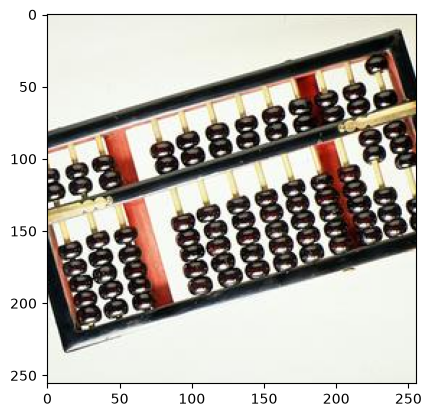

In [5]:
img = cv2.imread(os.path.join(path, 'abacus', '000.jpg'))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

1. Set the number of classes to 100 (for now)
2. Normalize pixel values of input images
3. Perform transformations so the model can't memorize exact pictures.
4. Create dataset & training-specific dataset and transform training dataset

# 2. Preprocess Data

`ToTensor()` already scales PIL images to tensor, so we don't need to perform manual scaling. Let's move to train-test-validation split.

1. Pick Images & Train-Test Split

In [6]:
NUM_CLASSES = None      # None keeps all 1000
dataset = datasets.ImageFolder(root=path, transform=transforms.ToTensor())

if NUM_CLASSES is not None:
    keep = sorted(random.Random(42).sample(dataset.classes, NUM_CLASSES))
    new_idx = {c: i for i, c in enumerate(keep)}
    keepset = set(keep)
    dataset.samples = [(p, new_idx[dataset.classes[l]]) for p, l in dataset.samples
                       if dataset.classes[l] in keepset]
    dataset.imgs = dataset.samples          # keep .imgs in sync
    dataset.targets = [l for _, l in dataset.samples]
    dataset.classes = keep
    dataset.class_to_idx = new_idx

g = torch.Generator().manual_seed(42) #control randomness for reproducibility
tr_i, va_i, te_i = random_split(range(len(dataset)), [0.7, 0.2, 0.1], generator=g)

2. Measure Mean/STD for Normalization (do not run unless needed)

In [25]:
# Run ONCE to produce the MEAN/STD in cell 10. Re-run only if NUM_CLASSES or
# either seed changes. Builds its own un-normalised copy on purpose.
raw = datasets.ImageFolder(root=path, transform=transforms.ToTensor())
if NUM_CLASSES is not None:
    raw.samples = [(p, l) for p, l in raw.samples if raw.classes[l] in keepset]
    raw.imgs = raw.samples

stat_loader = DataLoader(Subset(raw, list(tr_i)), batch_size=256, num_workers=8)
channel_sum, channel_sq_sum, count = torch.zeros(3), torch.zeros(3), 0
for images, _ in stat_loader:
    b = images.shape[0]
    pixels = images.view(b, 3, -1)          # (b,3,H,W) -> (b,3,H*W)
    channel_sum    += pixels.mean(2).sum(0)
    channel_sq_sum += (pixels ** 2).mean(2).sum(0)
    count          += b
mean = channel_sum / count
std  = (channel_sq_sum / count - mean ** 2).sqrt()   # sqrt(E[x^2] - E[x]^2)
print("MEAN =", [round(v, 4) for v in mean.tolist()])
print("STD  =", [round(v, 4) for v in std.tolist()])

MEAN = [0.4755, 0.4443, 0.3913]
STD  = [0.2751, 0.2664, 0.2772]


3. Transform + load data

In [ ]:
# per-channel stats of all 377,879 training images; see the stats cell below
MEAN = [0.4755, 0.4443, 0.3913]
STD  = [0.2751, 0.2664, 0.2772]

train_tfm = transforms.Compose([transforms.RandomCrop(224),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(),
                                transforms.Normalize(MEAN, STD)])
eval_tfm  = transforms.Compose([transforms.CenterCrop(224),
                                transforms.ToTensor(),
                                transforms.Normalize(MEAN, STD)])

dataset.transform = eval_tfm
train_dataset = copy.copy(dataset)          # same files, augmented transform
train_dataset.transform = train_tfm

train_loader = DataLoader(Subset(train_dataset, list(tr_i)), batch_size=128,
                          shuffle=True,  num_workers=8, persistent_workers=True)
val_loader   = DataLoader(Subset(dataset, list(va_i)), batch_size=256,
                          shuffle=False, num_workers=8, persistent_workers=True)
test_loader  = DataLoader(Subset(dataset, list(te_i)), batch_size=256,
                          shuffle=False, num_workers=8)

Display subset of a batch to confirm data was successfully loaded

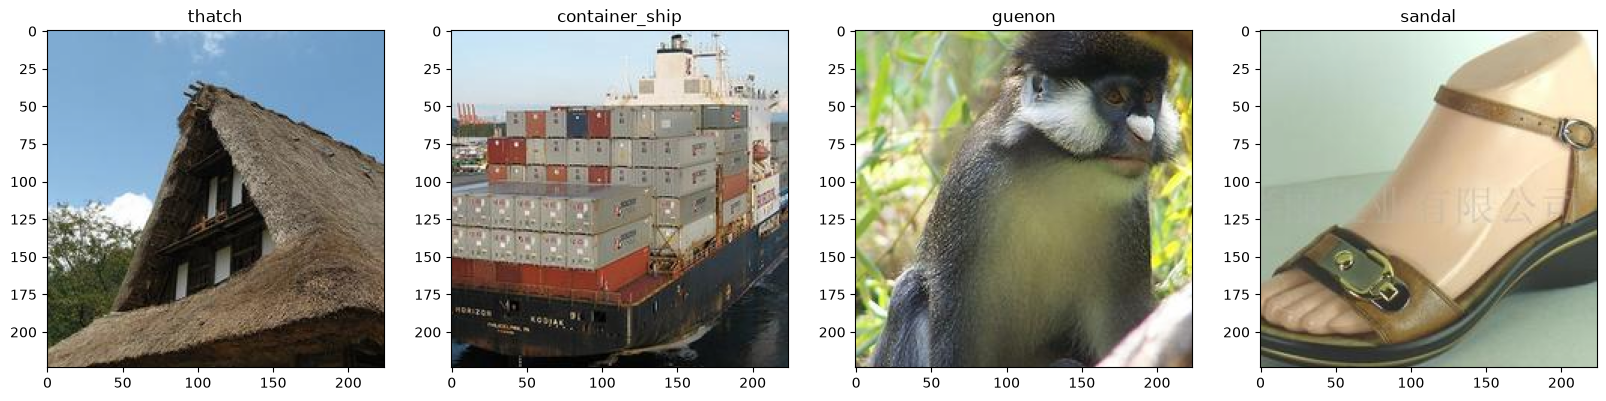

In [8]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
data_iterator = iter(dataloader)
batch = next(data_iterator)

fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    image = img.permute(1, 2, 0).numpy()
    image = (image * np.array(STD) + np.array(MEAN)).clip(0, 1)  # unnormalize
    ax[idx].imshow(image)
    label = dataset.classes[batch[1][idx]]
    ax[idx].title.set_text(label)

Calculate mean and std of our batches.

# 3. Build Model

In [9]:
# Linear is Pytorch's version of Tensorflow's Dense layer
from torch.nn import (Module, Conv2d, BatchNorm2d, MaxPool2d, Linear,
                      AdaptiveAvgPool2d, Flatten, ReLU, Sequential, Dropout)
import torch.optim as optim

In [ ]:
# Old model architecture, kept for reference
""" 
class CNN(Module):
    def __init__(self, num_classes):
        super().__init__()
        # Our input layer has size (3, 256, 256) (3 channels, 256x256 pixels)
        # (3, 256, 256) -> (32, 256, 256); padding=1 to keep the same size after convolution
        self.conv1 = Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = BatchNorm2d(32)
        # (32, 256, 256) -> (64, 256, 256); padding=1 to keep the same size after convolution
        self.conv2 = Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = BatchNorm2d(64)
        # (64, 256, 256) -> (128, 256, 256); padding=1 to keep the same size after convolution
        self.conv3 = Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = BatchNorm2d(128)
        # (128, 256, 256) -> (128, 128, 128); max pooling reduces the size by half
        self.pool = MaxPool2d(kernel_size=2, stride=2)

        # reduce the global feature map to (128, 1, 1)
        self.gap = AdaptiveAvgPool2d(1)
        # flatten the feature map to (128,)
        self.flat = Flatten()
        # activation function
        self.relu = ReLU()

        # fully connected layer
        self.dense1 = Linear(in_features=128, out_features=256)
        # dropout layer to prevent overfitting
        self.dropout = Dropout(p=0.2)
        # fully connected layer to output the number of classes
        self.dense2 = Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        # apply convolutional layers with ReLU activation, max pooling, and batch normalization
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))


        # apply global average pooling and flatten the feature map
        x = self.flat(self.gap(x))
        # apply fully connected layers with ReLU activation and dropout
        x = self.relu(self.dense1(x))
        x = self.dropout(x)
        x = self.dense2(x)

        return x
"""

In [ ]:
def conv_block(in_ch, out_ch, stride=1):
    """Conv -> BatchNorm -> ReLU, the unit this network repeats."""
    return Sequential(Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                      BatchNorm2d(out_ch), ReLU())


class DeepCNN(Module):
    def __init__(self, num_classes):
        super().__init__()
        # stem: halves the image right away, 224 -> 112
        self.stem = conv_block(3, 32, stride=2)

        # each stage: two convs, then pool halves the grid
        self.conv1a = conv_block(32, 32)      # 112 -> 56 after pool
        self.conv1b = conv_block(32, 32)

        self.conv2a = conv_block(32, 64)      # 56 -> 28
        self.conv2b = conv_block(64, 64)

        self.conv3a = conv_block(64, 128)     # 28 -> 14
        self.conv3b = conv_block(128, 128)

        self.conv4a = conv_block(128, 256)    # 14 -> 7
        self.conv4b = conv_block(256, 256)
        self.conv4c = conv_block(256, 256)    # 7 -> 3 after pool

        self.conv5a = conv_block(256, 512)    # 7 -> 3 after pool
        self.conv5b = conv_block(512, 512)
        self.conv5c = conv_block(512, 512)    # 3 -> 1 after pool

        self.pool = MaxPool2d(2, 2)
        self.gap  = AdaptiveAvgPool2d(1)
        self.flat = Flatten()
        self.drop = Dropout(0.2)
        self.fc = Linear(512, num_classes)    # was 256

    def forward(self, x):
        x = self.stem(x)
        x = self.pool(self.conv1b(self.conv1a(x)))
        x = self.pool(self.conv2b(self.conv2a(x)))
        x = self.pool(self.conv3b(self.conv3a(x)))
        x = self.pool(self.conv4b(self.conv4a(x)))
        x = self.pool(self.conv5b(self.conv5a(x)))
        x = self.flat(self.gap(x))
        return self.fc(self.drop(x))

In [ ]:
EPOCHS = 40
cnn = DeepCNN(num_classes=len(dataset.classes)).to(device)
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
#optimizer = optim.SGD(cnn.parameters(), lr=0.01, momentum=0.9)
optimizer = optim.Adam(cnn.parameters(), lr=0.001, weight_decay=1e-4)
use_amp = (device.type == 'cuda')  # use automatic mixed precision only on CUDA devices
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [ ]:
CKPT = "checkpoint.pt"

start_epoch = 0
best_acc = 0.0
if os.path.exists(CKPT):
    ckpt = torch.load(CKPT)
    cnn.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    start_epoch = ckpt["epoch"] + 1
    print(f"resuming from epoch {start_epoch + 1}")


for epoch in range(start_epoch, EPOCHS):
    cnn.train()
    print(f"Epoch {epoch+1}/{EPOCHS}")
    running_loss = 0.0

    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast(device.type, dtype=torch.bfloat16, enabled=use_amp):
            outputs = cnn(inputs)
            loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"  batch {i}/{len(train_loader)} loss {loss.item():.4f}")

        running_loss += loss.item()

    print(f"Training loss: {running_loss/len(train_loader):.4f}")

    cnn.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad(), torch.autocast(device.type, dtype=torch.bfloat16, enabled=use_amp):
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = cnn(inputs)
            val_loss += loss_function(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    print(f"Val loss {val_loss/len(val_loader):.4f} | Val acc {100*correct/total:.2f}%")

    val_acc = 100 * correct / total
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(cnn.state_dict(), "best.pt")
        print(f"  new best: {best_acc:.2f}% -> saved")

    scheduler.step()

    torch.save({"epoch": epoch,
                "best_acc": best_acc,
                "model": cnn.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict()}, CKPT)

In [34]:
torch.save(cnn.state_dict(), "deepcnn_1000cls.pt")

In [ ]:
cnn.eval()
test_loss, correct, total = 0.0, 0, 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = cnn(inputs)
        test_loss += loss_function(outputs, labels).item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
print(f"TEST loss {test_loss/len(test_loader):.4f} | TEST acc {100*correct/total:.2f}%")


TEST loss 2.8580 | TEST acc 55.98%


Class names dump for web app

In [36]:
import json
json.dump(dataset.classes, open("classes.json", "w"))

In [1]:
print('hi')

hi
